In [10]:
%matplotlib widget

import time
import matplotlib.pyplot as plt
from moku.instruments import FrequencyResponseAnalyzer
import traceback

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

## Estilo dos gráficos ######################################################################################################

plt.style.use('default') # Gráficos com fundo branco
# plt.rcParams["figure.autolayout"] = True
# plt.rcParams["figure.figsize"] = [16, 9] # [7, 4] # [8, 5]
plt.style.use({
    'figure.figsize': [7,4], 'figure.constrained_layout.use': True, #'text.usetex' : True,
    'axes.titlesize': 14, 'legend.fontsize': 10, 'axes.labelsize': 10,'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

Buscando o Moku:Go na rede pelo IP: 192.168.73.1 ...
Conexão bem-sucedida! Configurando o instrumento ...
Iniciando varredura ... (Script em espera)
Extraindo matrizes de dados da RAM...
Conexão encerrada


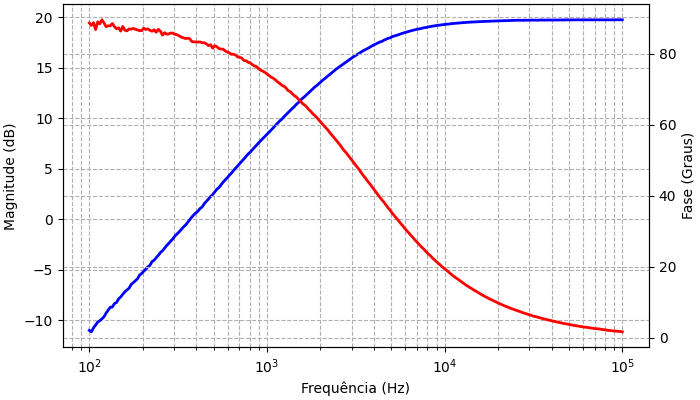

In [23]:
## CONEXÃO E COLETA DE DADOS ################################################################################################

MOKU_IP = '192.168.73.1' # IP do equipamento
FRA = None # Garante que a variável existe, mesmo se a conexão explodir. FRA: Frequency Response Analyzer

try:
    print(f"Buscando o Moku:Go na rede pelo IP: {MOKU_IP} ...")
    FRA = FrequencyResponseAnalyzer(MOKU_IP, force_connect=True) # 'force_connect=True' garante controle mesmo com o app aberto
    print("Conexão bem-sucedida! Configurando o instrumento ...")
    
    # 1. Configura a varredura
    FRA.set_sweep(
        start_frequency=100, stop_frequency=100e3, num_points=256,
        settling_cycles=2, averaging_cycles=2, strict=False
    )
    FRA.set_output(1, amplitude=1.0, offset=0.0)
    
    # 3. Inicia a varredura, espera terminar e extrai os dados
    print("Iniciando varredura ... (Script em espera)")
    FRA.start_sweep()
    data = FRA.get_data(wait_complete=True)
    
    # 4. Extração e Tratamento dos Dados (Convertendo saída do Moku para Arrays do NumPy)
    print("Extraindo matrizes de dados da RAM...")
    freqs = np.array(data['ch1']['frequency'])

    # Chaves da API do MokuGo ('magnitude' e 'phase')
    mag_ch1 = np.array(data['ch1']['magnitude'])
    mag_ch2 = np.array(data['ch2']['magnitude'])
    phase_ch1 = np.array(data['ch1']['phase'])
    phase_ch2 = np.array(data['ch2']['phase'])
    
    # A atenuação real do filtro (CH2 - CH1) --> Magnitude (dB) = 20 * log10(|Vout/Vin|) = Mag_CH2(dB) - Mag_CH1(dB)
    transfer_magnitude = mag_ch2 - mag_ch1
    transfer_phase = np.rad2deg( np.unwrap( np.deg2rad(phase_ch2 - phase_ch1) ) ) # Unwrap da fase para evitar saltos de 360 graus

    # 5. Visualização Rápida
    fig, ax1 = plt.subplots( figsize=(7, 4), sharex=True)
    
    ax1.semilogx(freqs, transfer_magnitude, color='b', linewidth=2)
    ax1.set_xlabel('Frequência (Hz)')
    ax1.set_ylabel('Magnitude (dB)')
    ax1.grid(True, which="both", ls="--")
    
    ax2 = ax1.twinx()
    ax2.semilogx(freqs, transfer_phase, color='r', linewidth=2)
    ax2.set_xlabel('Frequência (Hz)')
    ax2.set_ylabel('Fase (Graus)')
    ax2.grid(True, which="both", ls="--")

except Exception as e:
    traceback.print_exc()

finally: # Libera o instrumento para não travar o Moku:Go
    if FRA is not None: # Só libera se o instrumento estava conectado
        FRA.relinquish_ownership()
        print("Conexão encerrada")

Palpites Iniciais: fc = 3572.24 Hz, T_pass = 19.73 dB

--- RESULTADOS DA OTIMIZAÇÃO ---
Frequência de Corte Real (fc): 3565.79 Hz ± 2.64 Hz
Transmissão na Banda de Passagem : 19.76 dB


C:\Users\Varlei\AppData\Local\Temp\ipykernel_10328\4019515215.py:48: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
C:\Users\Varlei\AppData\Local\Temp\ipykernel_10328\4019515215.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


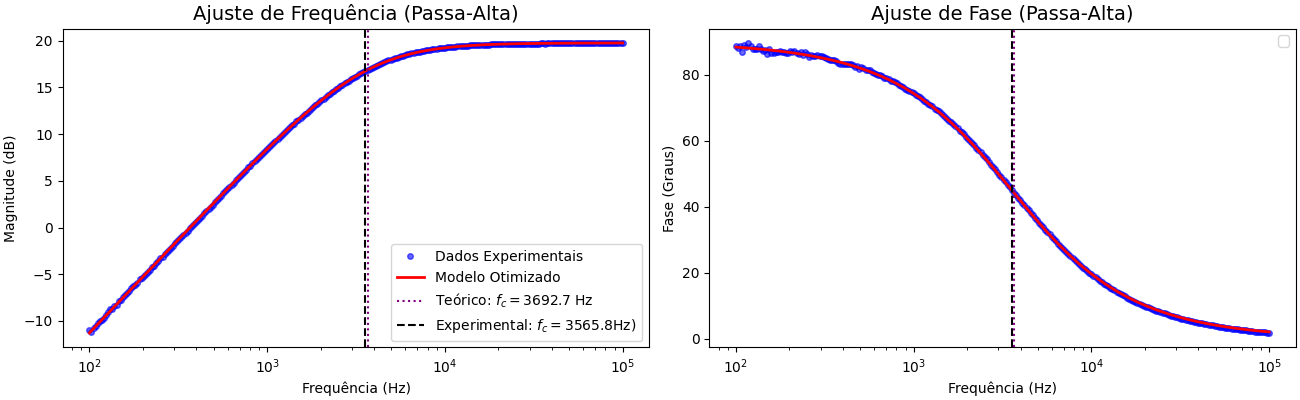

In [ ]:
## OTIMIZAÇÃO DE CURVA (Curve Fit) ##########################################################################################
R_teo, C_teo = 4.31e3, 10e-9
fc_teo = 1/(2*np.pi * R_teo * C_teo)

# 1. Colocando os dados no Pandas
df = pd.DataFrame({
    'Frequency'   : freqs,
    'Magnitude_dB': transfer_magnitude,
    'Phase_deg'   : transfer_phase
})

# 2. Definindo o modelo matemático com correção experimental
def Transmissao_dB(f, fc, T_pass):
    return 20 * np.log10(f / fc) - 10 * np.log10( 1 + (f / fc)**2 ) + T_pass

def Fase_graus(f, fc):
    return np.rad2deg( np.arctan(fc / f) )

# 3. Palpites Iniciais (p0) Dinâmicos
T_pass = df['Magnitude_dB'].max() # Transmissão na banda de passagem (máximo; idealmente T ~ 0dB)
Tc = T_pass - 3 # Transmissão de corte (queda de 3dB; idealmente T ~ -3dB)
idx_fc = (df['Magnitude_dB'] - Tc).abs().argmin() # Índice da queda de 3dB
fc = df['Frequency'].iloc[idx_fc] # Frequência de corte (T ~ -3dB)

print(f"Palpites Iniciais: fc = {fc:.2f} Hz, T_pass = {T_pass:.2f} dB")

# 4. O Ajuste Fino (Curve Fit)
try:
    popt, pcov = curve_fit(
        f=Transmissao_dB,
        xdata=df['Frequency'],
        ydata=df['Magnitude_dB'],
        p0=[fc, T_pass],
        bounds=([0, -np.inf], [np.inf, np.inf]) # fc > 0, T_dB livre
    )
    
    fc_opt, T_pass_opt = popt # Parâmetros Otimizados
    fc_sig = np.sqrt(pcov[0, 0]) # Diagonal da matriz de covariância é a variância dos parâmetros.
    
    print("\n--- RESULTADOS DA OTIMIZAÇÃO ---")
    print(f"Frequência de Corte Real (fc): {fc_opt:.2f} Hz ± {fc_sig:.2f} Hz")
    print(f"Transmissão na Banda de Passagem : {T_pass_opt:.2f} dB")
    
    # 5. Plotando para verificar a sanidade do ajuste
    df['Fitted_Magnitude'] = Transmissao_dB(df['Frequency'], fc_opt, T_pass_opt)
    df['Fitted_Phase'] = Fase_graus(df['Frequency'], fc_opt)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

    ax1.semilogx(df['Frequency'], df['Magnitude_dB'], 'bo', label='Dados Experimentais', markersize=4, alpha=0.6)
    ax1.semilogx(df['Frequency'], df['Fitted_Magnitude'], 'r-', label=f'Modelo Otimizado', linewidth=2)
    ax1.axvline(fc_teo, color='purple', linestyle=':', label=f'Teórico: $f_c=${fc_teo:.1f} Hz')
    ax1.axvline(fc_opt, color='k', linestyle='--', label=f'Experimental: $f_c =${fc_opt:.1f}Hz)')
    ax1.set_title('Ajuste de Frequência (Passa-Alta)')
    ax1.set_xlabel('Frequência (Hz)')
    ax1.set_ylabel('Magnitude (dB)')
    ax1.legend()

    ax2.semilogx(df['Frequency'], df['Phase_deg'], 'bo', markersize=4, alpha=0.6)
    ax2.semilogx(df['Frequency'], df['Fitted_Phase'], 'r-', linewidth=2)
    ax2.axvline(fc_opt, color='k', linestyle='--')
    ax2.axvline(fc_teo, color='purple', linestyle=':')
    ax2.set_title('Ajuste de Fase (Passa-Alta)')
    ax2.set_xlabel('Frequência (Hz)')
    ax2.set_ylabel('Fase (Graus)')
    ax2.legend()

except RuntimeError:
    print("O SciPy não conseguiu convergir para uma solução. Verifique a qualidade dos seus dados ou o range da varredura.")